# CLIMBER-X DO Event Emulation & Calibration

**Goal:** Calibrate 6 ocean parameters of CLIMBER-X against Dansgaard–Oeschger (DO) event statistics of AMOC time series.

**Workflow (this notebook — emulation step):**
1. Load ensemble parameters and AMOC time series
2. Compute summary statistics on a fixed global AMOC grid
3. Fit PCA on ensemble KDE PDFs
4. Visualise example runs
5. Train a GP emulator: parameters → PCA components + scalar statistics
6. Evaluate with cross-validation and predict the default run

**Parameters:** `diff_dia_min`, `drag_topo_fac`, `slope_max`, `diff_iso`, `diff_gm`, `diff_dia_max`  
**Summary stats:** 5 PCA components of the AMOC PDF + `avg_waiting_time`, `avg_stadial_duration`, `avg_amplitude`, `mean`, `std`, `n_stadials`

## 1. Configuration

In [1]:
# ── Dataset configuration ────────────────────────────────────────────────────
# Switch between 'data' (75 kyr, 502 runs) and 'data2' (10 kyr, 300 runs)
# by changing ACTIVE_DATASET.

PPE_CONFIGS = {
    'data': {
        'data_dir':          'data',
        'run_length':        75000,   # expected years per run
        'spinup_fraction':   0.02,
        'do_crossing_value': 5.0,     # Sv — residual threshold for DO event detection
        'detection_mode':   'peak_walkback',
        'do_peak_threshold': 14.0,    # Sv — first KDE peak above this → non-DO run
        'prior_bounds': {
            'diff_dia_min':  (7.5e-6,   1.25e-5),
            'drag_topo_fac': (2.25,     3.75),
            'slope_max':     (7.5e-4,   1.25e-3),
            'diff_iso':      (1125,     1875),
            'diff_gm':       (1125,     1875),
            'diff_dia_max':  (1.125e-4, 1.875e-4),
        },
    },
    'data2': {
        'data_dir':          'data2',
        'run_length':        10000,
        'spinup_fraction':   0.1,
        'do_crossing_value': 3.6,
        'detection_mode':   'peak_walkback',
        'do_peak_threshold': 14.0,
        'prior_bounds': {
            'diff_dia_min':  (0.5e-5,  2.0e-5),
            'drag_topo_fac': (2.5,     3.5),
            'slope_max':     (0.5e-3,  2.0e-3),
            'diff_iso':      (500,     2000),
            'diff_gm':       (500,     2000),
            'diff_dia_max':  (1.0e-4,  2.0e-4),
        },
    },
}

ACTIVE_DATASET = 'data'   # ← change here to switch

# Path to the default/target CLIMBER-X run (calibration target)
DEFAULT_RUN_FILE = '../emulator/climberx_output/default_long_run/ocn_ts.nc'

# Number of PCA components to retain for the AMOC PDF
N_PCA = 5

# ─────────────────────────────────────────────────────────────────────────────
cfg               = PPE_CONFIGS[ACTIVE_DATASET]
DATA_DIR          = cfg['data_dir']
spinup_fraction   = cfg['spinup_fraction']
do_crossing_value = cfg['do_crossing_value']
detection_mode    = cfg['detection_mode']
do_peak_threshold = cfg['do_peak_threshold']
prior_bounds      = cfg['prior_bounds']
param_names       = list(prior_bounds.keys())

print(f'Active dataset  : {ACTIVE_DATASET} ({DATA_DIR})')
print(f'Run length      : {cfg["run_length"]} yr')
print(f'Spinup fraction : {spinup_fraction}')
print(f'DO crossing     : {do_crossing_value} Sv')
print(f'DO peak thresh  : {do_peak_threshold} Sv')
print(f'PCA components  : {N_PCA}')

Active dataset  : data (data)
Run length      : 75000 yr
Spinup fraction : 0.02
DO crossing     : 5.0 Sv
DO peak thresh  : 14.0 Sv
PCA components  : 5


## 2. Data Loading

In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import importlib

import summary_stats as _ss; importlib.reload(_ss)
from summary_stats import compute_summary_stats

import utils as _ut; importlib.reload(_ut)
from utils import (
    plot_amoc_analysis, plot_filtered_runs,
    plot_pca_variance, plot_pca_components,
    plot_pca_predictions, plot_stat_predictions,
    plot_pdf_comparison, plot_correlation_heatmap,
)

import gp_emulator as _gp; importlib.reload(_gp)
from gp_emulator import GPEmulatorPDF, crossvalidation, print_cv_summary

# ── Parameter table ─────────────────────────────────────────────────────────
info = pd.read_csv(f'{DATA_DIR}/info.txt', delimiter=r'\s+')
ocn_cols = [c for c in info.columns if c.startswith('ocn.')]
if 'ocn.l_noise_fw' in ocn_cols:
    ocn_cols.remove('ocn.l_noise_fw')
params = info[['runid'] + ocn_cols]

print(f'Parameter table : {params.shape[0]} runs × {len(ocn_cols)} parameters')
print(params[ocn_cols].describe().round(6))

Parameter table : 500 runs × 6 parameters
       ocn.diff_dia_min  ocn.drag_topo_fac  ocn.slope_max  ocn.diff_iso  \
count        500.000000         500.000000     500.000000    500.000000   
mean           0.000010           2.999944       0.001000   1499.297979   
std            0.000002           0.231396       0.000231    230.841389   
min            0.000006           2.601582       0.000600   1100.080860   
25%            0.000008           2.799612       0.000800   1299.866116   
50%            0.000010           2.999033       0.001000   1499.349900   
75%            0.000012           3.200231       0.001200   1698.109456   
max            0.000014           3.398624       0.001400   1899.769685   

       ocn.diff_gm  ocn.diff_dia_max  
count   500.000000        500.000000  
mean   1500.325846          0.000150  
std     231.311277          0.000023  
min    1100.792227          0.000110  
25%    1300.397590          0.000130  
50%    1500.796199          0.000150  
75%    17

In [3]:
# ── Build file list ──────────────────────────────────────────────────────────
run_ids_in_dir = sorted(
    int(d) for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d)) and d.isdigit()
)
max_run_id = max(run_ids_in_dir)
print(f'Found {len(run_ids_in_dir)} run directories in {DATA_DIR!r},  max ID = {max_run_id}')

model_files = []
missing_ids = []
for run_id in range(1, max_run_id + 1):
    fp = f'{DATA_DIR}/{run_id}/ocn_ts.nc'
    if os.path.exists(fp):
        model_files.append(fp)
    else:
        missing_ids.append(run_id)
        model_files.append(None)

print(f'Missing runs ({len(missing_ids)}): {missing_ids}')

Found 500 run directories in 'data',  max ID = 500
Missing runs (17): [186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202]


## 3. Summary Statistics

All KDE PDFs are evaluated on a **fixed global x-grid** (1st–99th percentile of AMOC across the full ensemble, 100 points).  
A shared grid is required for PCA: every PDF must be a vector in the same Euclidean space.

- **DO runs** (first KDE peak ≤ `do_peak_threshold`): genuine stadial variability.
- **Non-DO runs** (wild oscillators): their DO-specific stats are zeroed.

In [4]:
from tqdm.notebook import tqdm

expected_length = cfg['run_length']

# ── Pass 1: collect global AMOC range, drop incomplete runs ──────────────────
print('Pass 1: reading AMOC ranges and filtering incomplete runs...')
all_amoc_concat = []
incomplete_run_ids = []

# Include default run in range estimation
if os.path.exists(DEFAULT_RUN_FILE):
    ds = xr.open_dataset(DEFAULT_RUN_FILE)
    amoc_default_raw = ds.amoc26N.values
    time_default_raw = ds.time.values
    ds.close()
    s0 = int(len(amoc_default_raw) * 0.02)
    all_amoc_concat.append(amoc_default_raw[s0:])
    print(f'Default run loaded: {len(amoc_default_raw)} yr')
else:
    amoc_default_raw = None
    print(f'WARNING: default run not found at {DEFAULT_RUN_FILE!r}')

for i, file in enumerate(tqdm(model_files, desc='Pass 1')):
    if file is None:
        continue
    ds = xr.open_dataset(file)
    amoc = ds.amoc26N.values
    ds.close()
    if len(amoc) < expected_length:
        incomplete_run_ids.append(i + 1)
        model_files[i] = None
    else:
        s = int(len(amoc) * spinup_fraction)
        all_amoc_concat.append(amoc[s:])

print(f'Incomplete runs excluded ({len(incomplete_run_ids)}): {incomplete_run_ids}')

all_amoc_flat = np.concatenate(all_amoc_concat)
global_min    = np.percentile(all_amoc_flat, 1)
global_max    = np.percentile(all_amoc_flat, 99)
global_x_grid = np.linspace(global_min, global_max, 100)

print(f'Global AMOC range (1–99th pct): [{global_min:.2f}, {global_max:.2f}] Sv')
print(f'Fixed x-grid: {len(global_x_grid)} points')

Pass 1: reading AMOC ranges and filtering incomplete runs...
Default run loaded: 75000 yr


Pass 1:   0%|          | 0/500 [00:00<?, ?it/s]

Incomplete runs excluded (8): [131, 136, 164, 171, 205, 405, 442, 448]
Global AMOC range (1–99th pct): [5.05, 28.57] Sv
Fixed x-grid: 100 points


In [5]:
# ── Pass 2: compute summary stats for default run ────────────────────────────
if amoc_default_raw is not None:
    default_stats = compute_summary_stats(
        amoc_default_raw, time_default_raw,
        x_grid=global_x_grid,
        spinup_fraction=0.02,
        do_crossing_value=5.0,
        detection_mode='peak_walkback',
        do_peak_threshold=do_peak_threshold,
    )
    print(f'Default run — DO variability: {default_stats["do_variability"]}')
    print(f'  N DO events        : {default_stats["n_do_events"]}')
    print(f'  Avg waiting time   : {default_stats["avg_waiting_time"]:.1f} yr')
    print(f'  Avg stadial dur.   : {default_stats["avg_stadial_duration"]:.1f} yr')
    print(f'  Avg amplitude      : {default_stats["avg_amplitude"]:.2f} Sv')
    print(f'  AMOC mean / std    : {default_stats["mean"]:.2f} / {default_stats["std"]:.2f} Sv')
else:
    default_stats = None

Default run — DO variability: True
  N DO events        : 51
  Avg waiting time   : 1451.9 yr
  Avg stadial dur.   : 813.3 yr
  Avg amplitude      : 18.77 Sv
  AMOC mean / std    : 12.60 / 6.16 Sv


In [6]:
# ── Pass 2: compute summary stats for ensemble ───────────────────────────────
ensemble_stats = []

for file in tqdm(model_files, desc='Summary stats'):
    if file is None:
        ensemble_stats.append(None)
        continue
    ds = xr.open_dataset(file)
    amoc = ds.amoc26N.values
    time = ds.time.values
    ds.close()
    stats = compute_summary_stats(
        amoc, time,
        x_grid=global_x_grid,
        spinup_fraction=spinup_fraction,
        do_crossing_value=do_crossing_value,
        detection_mode=detection_mode,
        do_peak_threshold=do_peak_threshold,
    )
    ensemble_stats.append(stats)

n_valid = sum(s is not None for s in ensemble_stats)
n_do    = sum(s is not None and s['do_variability'] for s in ensemble_stats)
print(f'Valid runs : {n_valid}')
print(f'DO runs    : {n_do} ({100*n_do/n_valid:.1f} %)')
print(f'Non-DO runs: {n_valid - n_do}')

Summary stats:   0%|          | 0/500 [00:00<?, ?it/s]

Valid runs : 475
DO runs    : 431 (90.7 %)
Non-DO runs: 44


In [7]:
# ── Fit PCA on all valid ensemble PDFs ──────────────────────────────────────
from sklearn.decomposition import PCA

all_pdfs = np.array([s['pdf'] for s in ensemble_stats if s is not None])
print(f'Fitting PCA on {len(all_pdfs)} PDFs  (shape {all_pdfs.shape})')

pca_model = PCA(n_components=N_PCA)
pca_model.fit(all_pdfs)

print(f'Explained variance ratio: {pca_model.explained_variance_ratio_.round(4)}')
print(f'Total variance explained: {pca_model.explained_variance_ratio_.sum()*100:.1f} %')

# Attach PCA scores to each stats dict
for stats in ensemble_stats:
    if stats is not None:
        stats['pca_components'] = pca_model.transform(stats['pdf'].reshape(1, -1)).flatten()

if default_stats is not None:
    default_stats['pca_components'] = pca_model.transform(
        default_stats['pdf'].reshape(1, -1)
    ).flatten()

Fitting PCA on 475 PDFs  (shape (475, 100))
Explained variance ratio: [0.5517 0.1614 0.1044 0.0715 0.0362]
Total variance explained: 92.5 %


## 4. Visualise Ensemble Runs

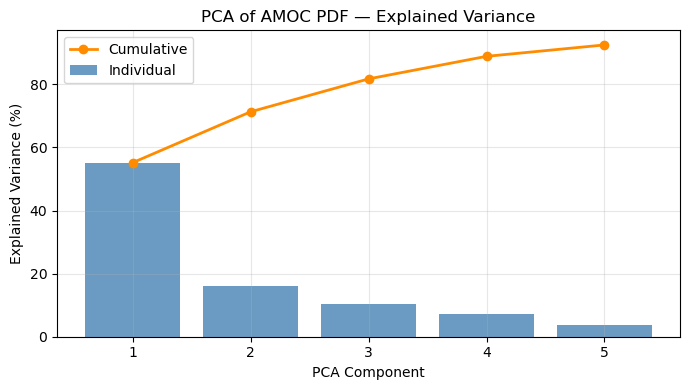

In [8]:
# PCA explained variance
fig = plot_pca_variance(pca_model)
plt.show()

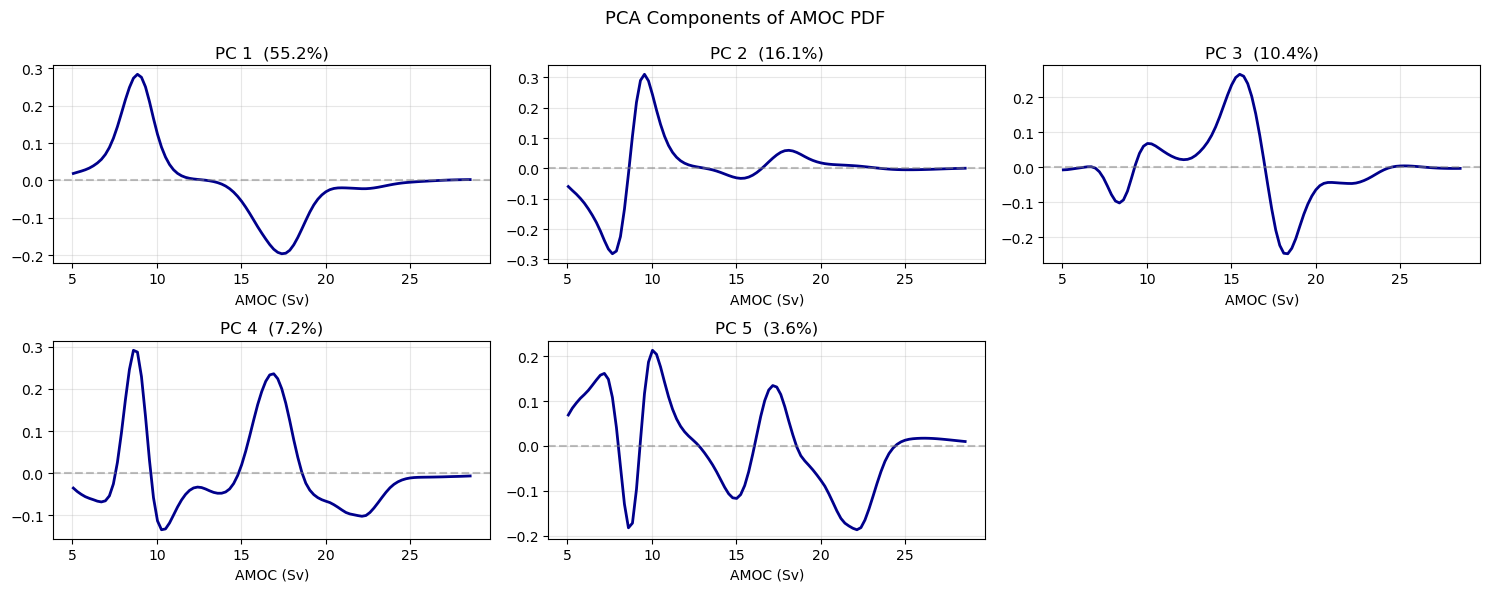

In [9]:
# PCA eigenvectors as functions of AMOC strength
fig = plot_pca_components(pca_model, global_x_grid, n_components=N_PCA)
plt.show()

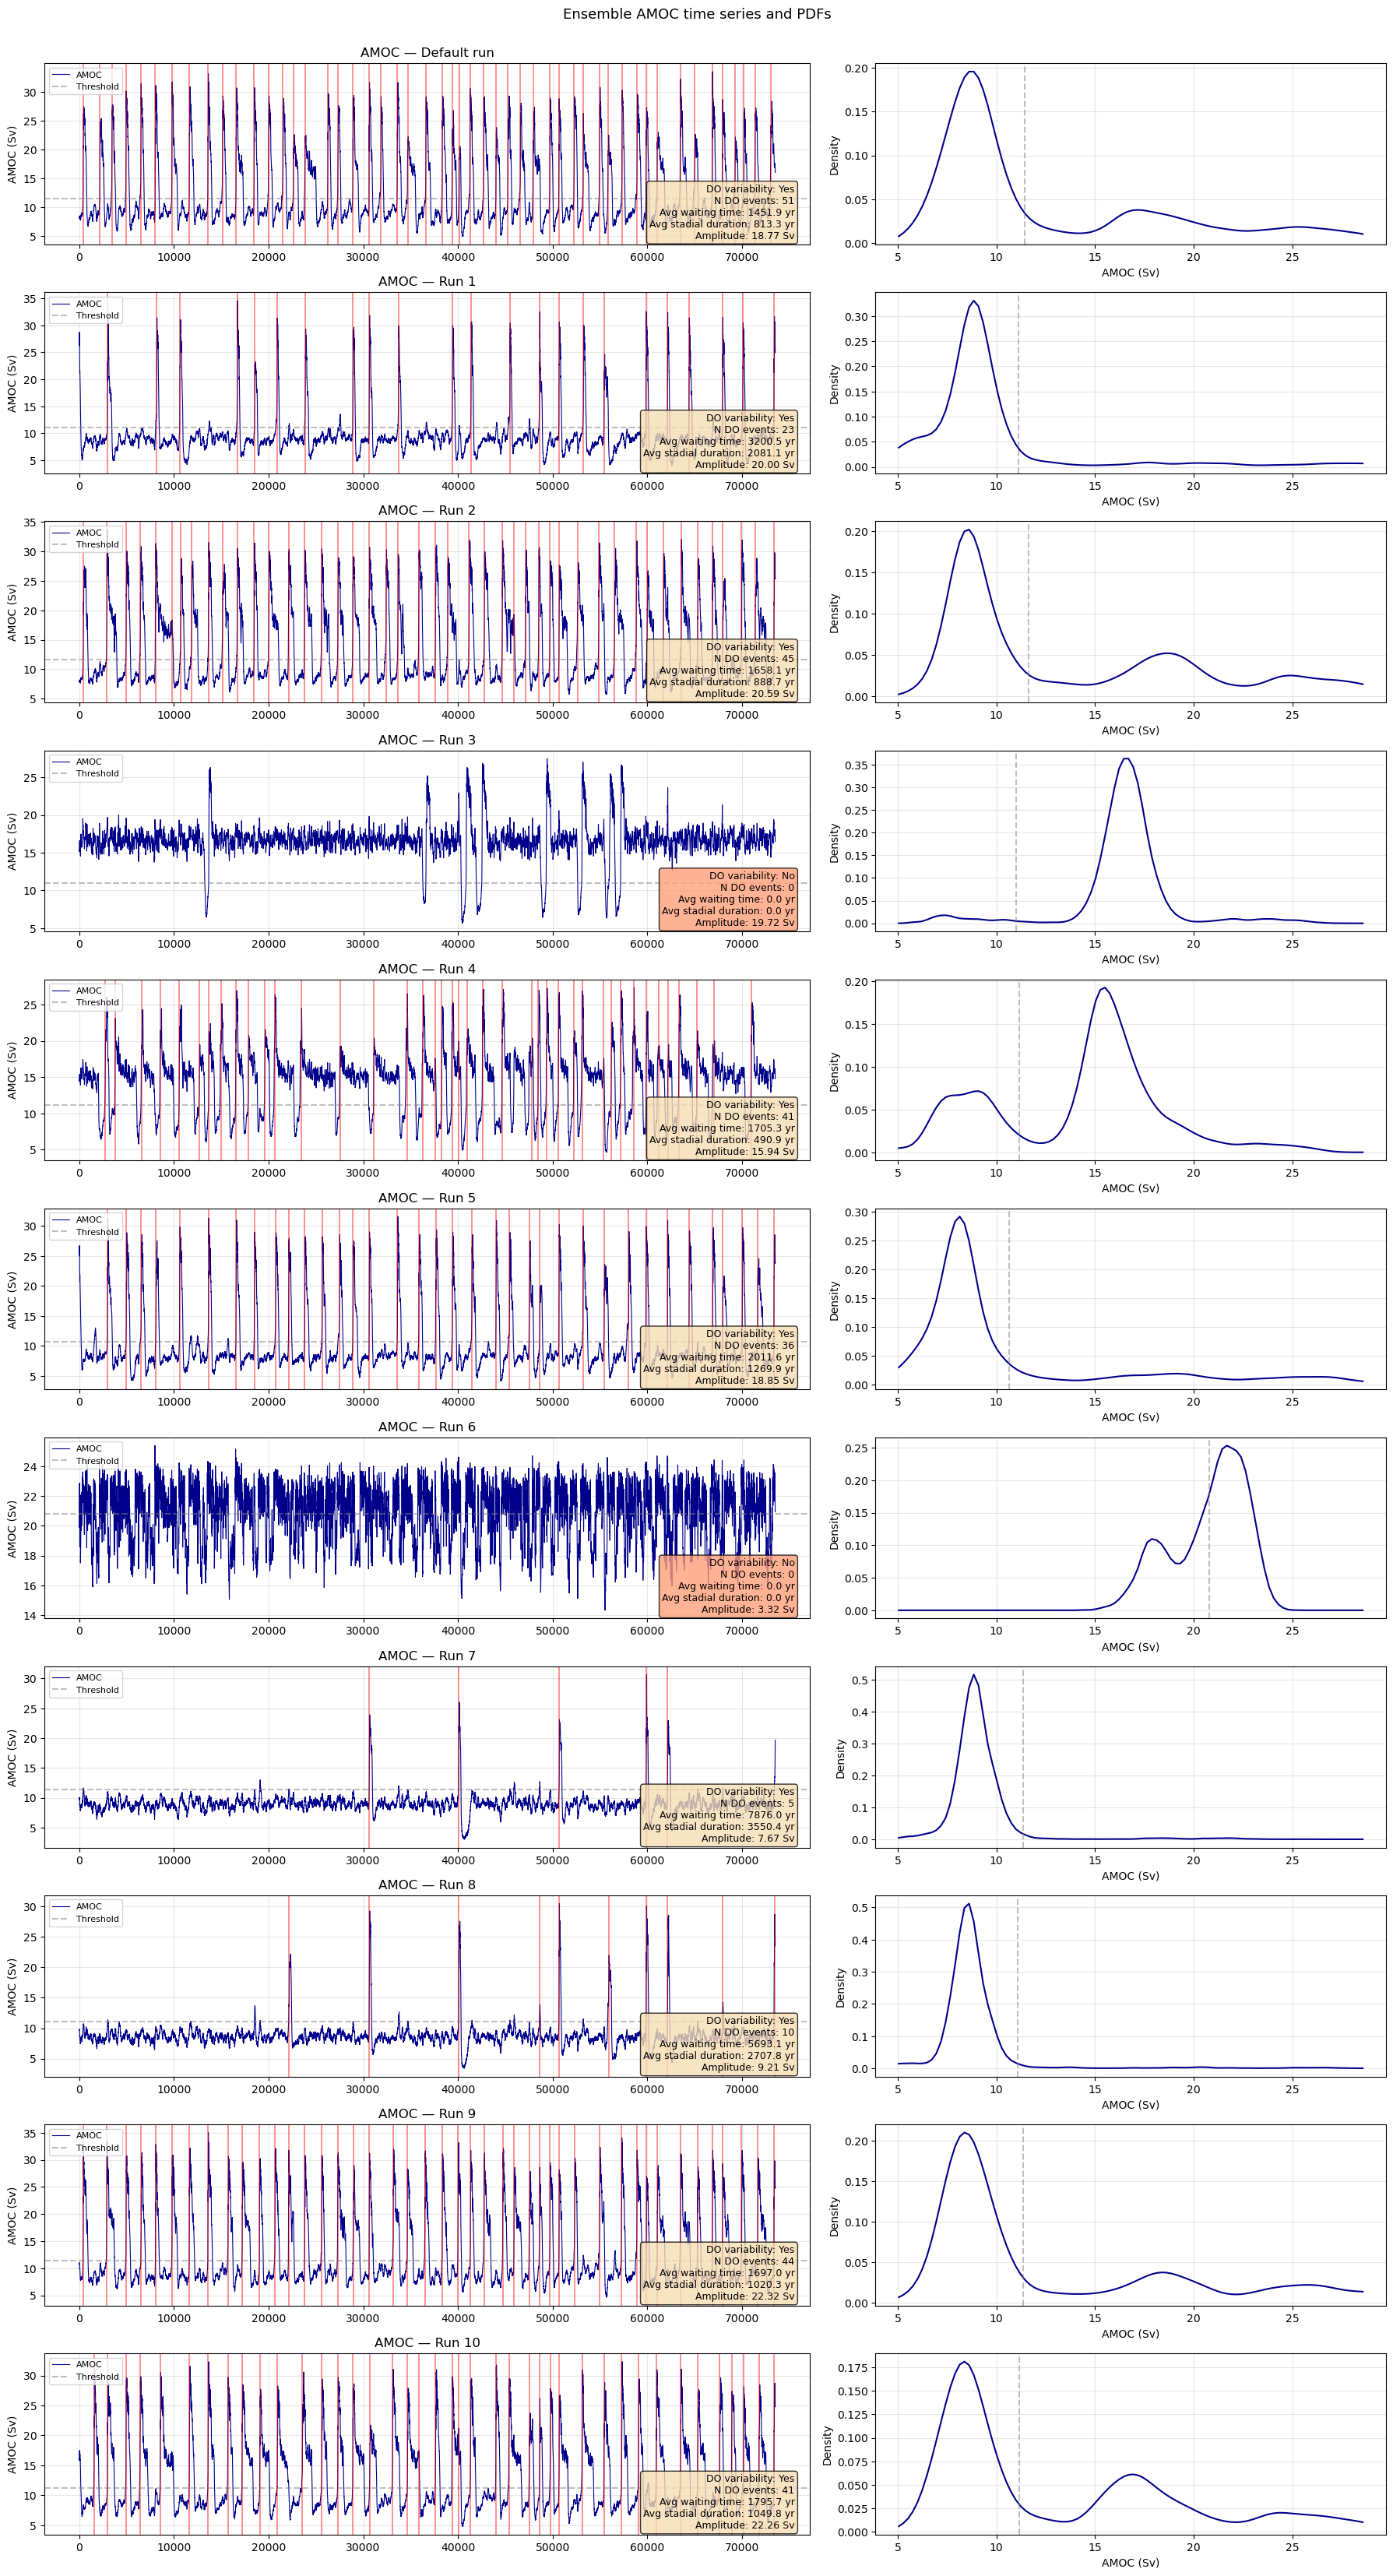

In [10]:
# AMOC time series + PDFs for the first 10 ensemble members
# (change n_runs or run_ids to select specific runs)
fig, axes = plot_amoc_analysis(
    ensemble_stats, model_files,
    default_stats=default_stats, default_file=DEFAULT_RUN_FILE,
    n_runs=10,
    spinup_fraction=spinup_fraction,
)
plt.suptitle('Ensemble AMOC time series and PDFs', fontsize=13, y=1.001)
plt.tight_layout()
plt.show()

In [11]:
# Example: plot only non-DO (wild oscillator) runs
non_do_mask = np.array([s is not None and not s['do_variability'] for s in ensemble_stats])
print(f'{non_do_mask.sum()} non-DO runs in ensemble')

# fig, axes = plot_filtered_runs(
#     ensemble_stats, model_files, non_do_mask,
#     default_stats=default_stats, default_file=DEFAULT_RUN_FILE,
#     max_runs=8, spinup_fraction=spinup_fraction,
# )
# plt.show()

44 non-DO runs in ensemble


## 5. Emulator Data Preparation

Train the GP emulator only on **DO runs** (first KDE peak ≤ `do_peak_threshold`).  
Wild oscillators are excluded: their DO statistics are not meaningful for calibration.

In [12]:
param_cols = [
    'ocn.diff_dia_min', 'ocn.drag_topo_fac', 'ocn.slope_max',
    'ocn.diff_iso', 'ocn.diff_gm', 'ocn.diff_dia_max',
]

# Valid ensemble runs (not None)
valid_mask    = np.array([s is not None for s in ensemble_stats])
valid_stats   = [s for s in ensemble_stats if s is not None]
params_valid  = params[valid_mask].reset_index(drop=True)

# DO-variability mask (within valid runs)
do_mask = np.array([s['do_variability'] for s in valid_stats])

# ── Build arrays for DO runs ─────────────────────────────────────────────────
X_all = params_valid[param_cols].values.astype(np.float64)

# Scalar summary statistics: [mean, std, avg_stadial_duration, avg_waiting_time,
#                              avg_amplitude, n_stadials]
STAT_COLS = ['mean', 'std', 'avg_stadial_duration', 'avg_waiting_time',
             'avg_amplitude', 'n_stadials']

other_stats_all = np.array([
    [s['mean'], s['std'], s['avg_stadial_duration'], s['avg_waiting_time'],
     s['avg_amplitude'], s['n_stadials']]
    for s in valid_stats
])

pca_all  = np.array([s['pca_components'] for s in valid_stats])
pdf_all  = np.array([s['pdf']            for s in valid_stats])

# Filter to DO runs
X            = X_all[do_mask]
other_stats  = other_stats_all[do_mask]
pca_components = pca_all[do_mask]
pdf_matrix   = pdf_all[do_mask]

print(f'Total valid runs : {len(valid_stats)}')
print(f'DO runs (train)  : {len(X)}')
print(f'X shape          : {X.shape}')
print(f'pca_components   : {pca_components.shape}')
print(f'other_stats      : {other_stats.shape}  cols={STAT_COLS}')
print(f'pdf_matrix       : {pdf_matrix.shape}')

Total valid runs : 475
DO runs (train)  : 431
X shape          : (431, 6)
pca_components   : (431, 5)
other_stats      : (431, 6)  cols=['mean', 'std', 'avg_stadial_duration', 'avg_waiting_time', 'avg_amplitude', 'n_stadials']
pdf_matrix       : (431, 100)


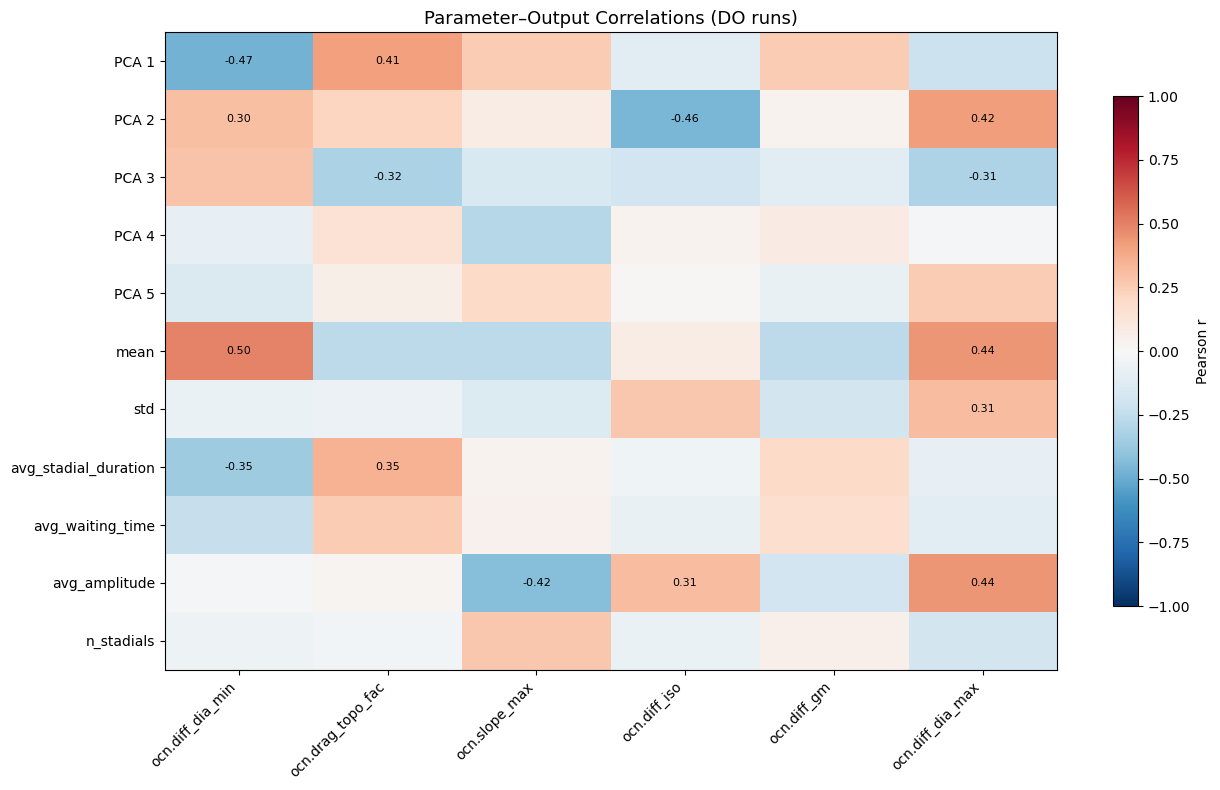

In [13]:
# ── Parameter-output correlation heatmap ────────────────────────────────────
output_labels = [f'PCA {i+1}' for i in range(N_PCA)] + STAT_COLS
Y_all_emul = np.hstack([pca_components, other_stats])

fig = plot_correlation_heatmap(
    X, Y_all_emul,
    param_names=param_cols,
    output_names=output_labels,
    title='Parameter–Output Correlations (DO runs)',
    figsize=(13, 8),
)
plt.show()

## 6. GP Emulator Training

In [14]:
from sklearn.gaussian_process.kernels import Matern
from sklearn.preprocessing import MinMaxScaler

kernel = 1.0 * Matern(length_scale=1.0, nu=1.5)

emulator = GPEmulatorPDF(kernel=kernel, scaler_X=MinMaxScaler())
emulator.pca        = pca_model
emulator.pdf_xpoints = global_x_grid

print('Fitting GP emulator on all DO runs...')
emulator.fit(X, other_stats, pca_components)
print(f'Emulator fitted:  {emulator.n_pca_components} PCA components + {other_stats.shape[1]} scalar stats')

Fitting GP emulator on all DO runs...
Emulator fitted:  5 PCA components + 6 scalar stats


## 7. Cross-Validation

In [15]:
print('Running 5-fold cross-validation...')
cv_results = crossvalidation(
    X=X,
    Y=other_stats,
    pca_components=pca_components,
    pdfs=pdf_matrix,
    emulator_class=GPEmulatorPDF,
    pca_model=pca_model,
    pdf_xpoints=global_x_grid,
    emulator_kwargs=dict(kernel=1.0 * Matern(length_scale=1.0, nu=1.5),
                         scaler_X=MinMaxScaler()),
    cv=5,
    output_names=STAT_COLS,
)

print_cv_summary(cv_results, output_names=STAT_COLS)

Running 5-fold cross-validation...
CROSS-VALIDATION SUMMARY

--- PCA Components ---
  Overall RMSE : 0.0782 ± 0.0016
  PCA 1       : 0.0992 ± 0.0069
  PCA 2       : 0.0948 ± 0.0152
  PCA 3       : 0.0601 ± 0.0072
  PCA 4       : 0.0739 ± 0.0076
  PCA 5       : 0.0477 ± 0.0073

--- PDF Reconstruction ---
  RMSE         : 0.0218 ± 0.0011
  Sup-norm     : 0.3313 ± 0.0349

--- Scalar Statistics ---
  mean                     : 0.5952 ± 0.0659
  std                      : 0.5937 ± 0.0949
  avg_stadial_duration     : 875.4840 ± 217.7728
  avg_waiting_time         : 2187.0949 ± 516.9999
  avg_amplitude            : 2.3510 ± 0.3097
  n_stadials               : 29.7730 ± 12.3809


## 8. Emulator Evaluation Plots

To generate these scatter plots we run one held-out 20 % test split (separate from CV).

In [16]:
from sklearn.model_selection import train_test_split

(
    X_train, X_test,
    pca_train, pca_test,
    pdf_train, pdf_test,
    Y_train, Y_test,
) = train_test_split(
    X, pca_components, pdf_matrix, other_stats,
    test_size=0.2, random_state=42,
)

emul_eval = GPEmulatorPDF(kernel=1.0 * Matern(length_scale=1.0, nu=1.5),
                          scaler_X=MinMaxScaler())
emul_eval.pca         = pca_model
emul_eval.pdf_xpoints = global_x_grid
emul_eval.fit(X_train, Y_train, pca_train)

pca_pred, Y_pred, pca_std, Y_std = emul_eval.predict(X_test)
pdf_pred = emul_eval.reconstruct_pdf(pca_pred)

print(f'Test set: {len(X_test)} runs')

Test set: 87 runs


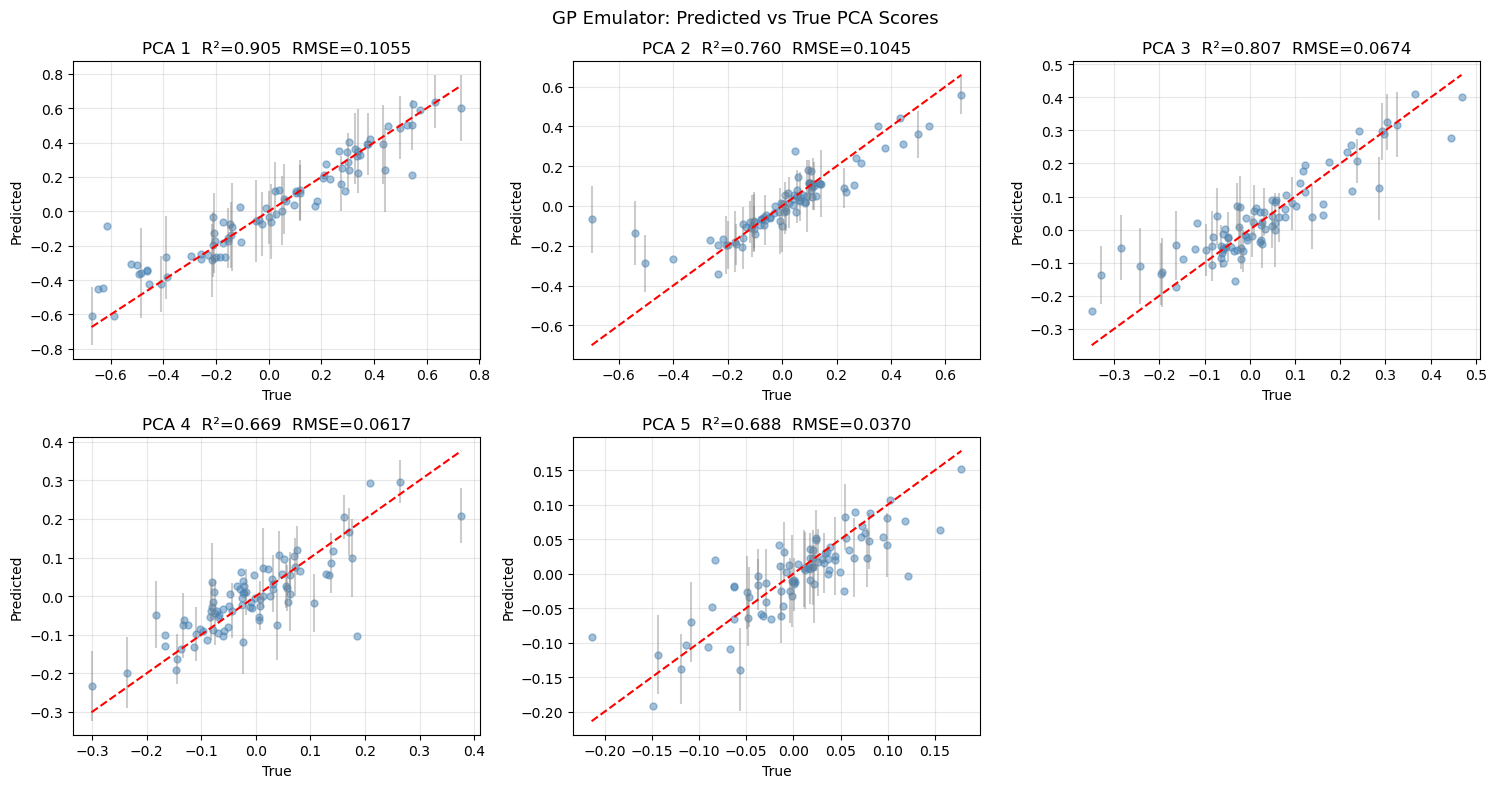

In [17]:
# Predicted vs true PCA scores
fig = plot_pca_predictions(pca_test, pca_pred, pca_std=pca_std)
plt.show()

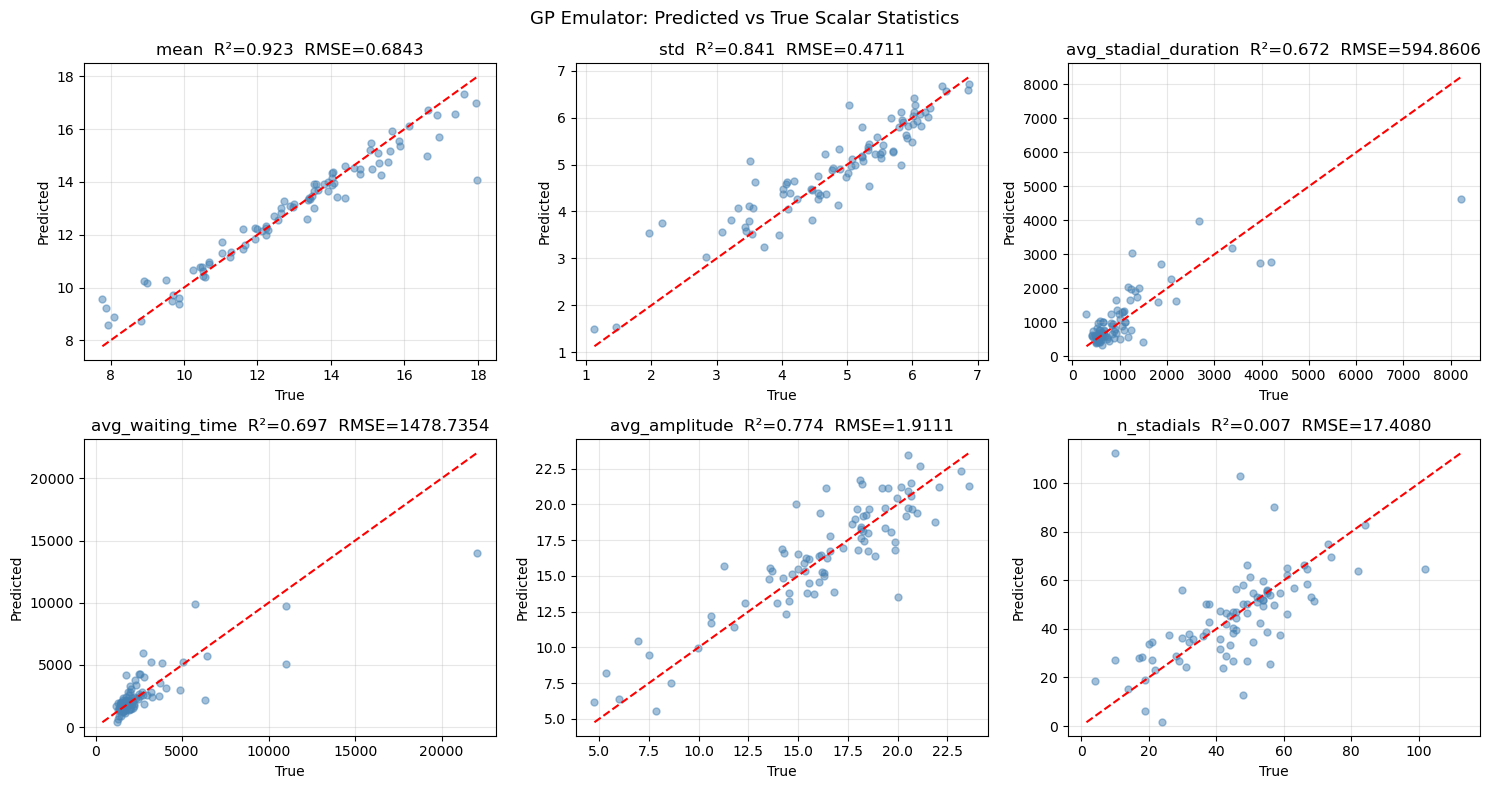

In [18]:
# Predicted vs true scalar statistics
fig = plot_stat_predictions(Y_test, Y_pred, stat_names=STAT_COLS)
plt.show()

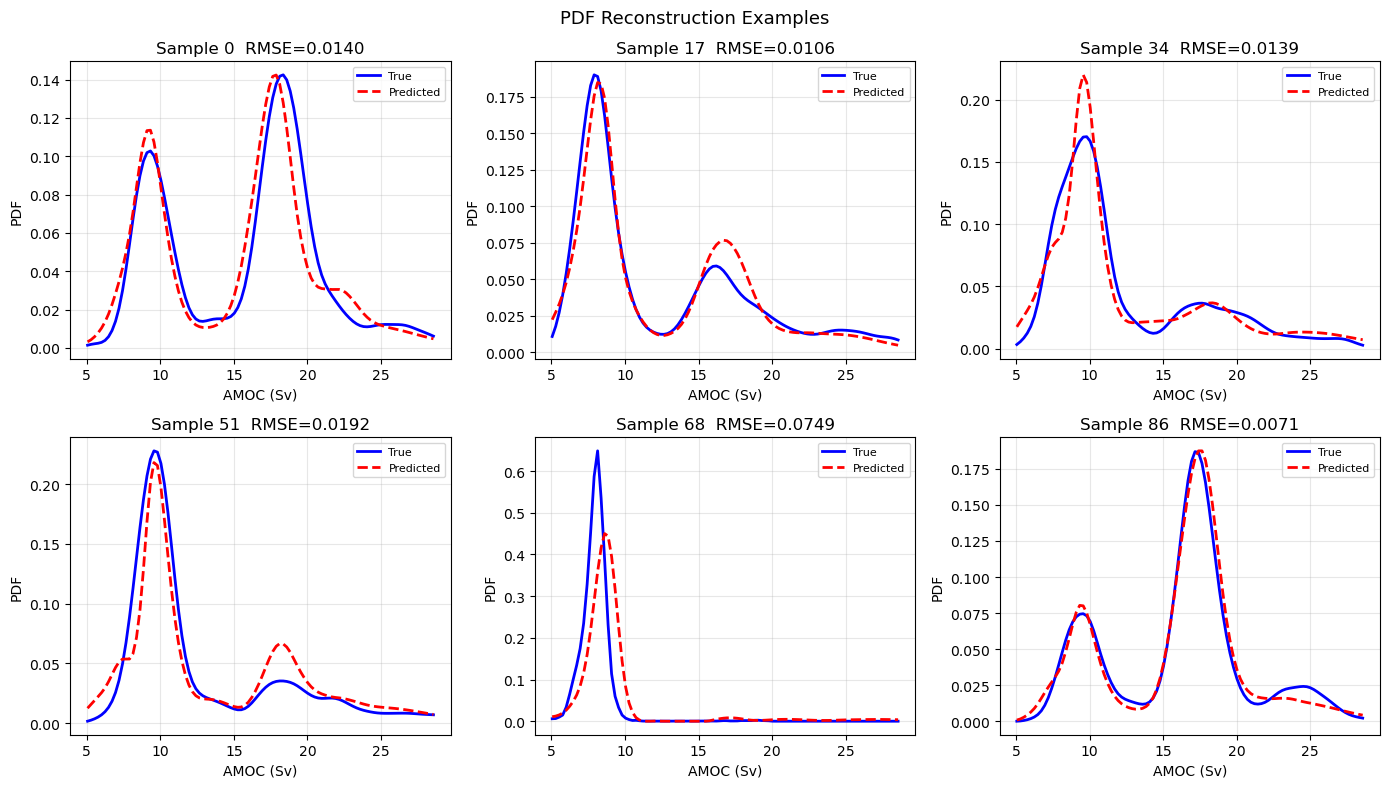

In [19]:
# PDF reconstruction examples
fig = plot_pdf_comparison(pdf_test, pdf_pred, global_x_grid, n_examples=6)
plt.show()

## 9. Predict Default Run

Use the full-data emulator to predict what the emulator would output for the default CLIMBER-X parameters, and compare with the actual default run statistics.

In [20]:
# Default parameter values
X_default = np.array([[
    1e-05,    # diff_dia_min
    3.0,      # drag_topo_fac
    0.001,    # slope_max
    1500.0,   # diff_iso
    1500.0,   # diff_gm
    1.5e-04,  # diff_dia_max
]])

pca_pred_def, Y_pred_def, pca_std_def, Y_std_def = emulator.predict(X_default)
pdf_pred_def = emulator.reconstruct_pdf(pca_pred_def)

print('Emulator prediction for default parameters:')
print(f'  PCA scores : {pca_pred_def[0].round(4)}')
print(f'  PCA std    : {pca_std_def[0].round(4)}')
print()
for i, name in enumerate(STAT_COLS):
    pred = Y_pred_def[0, i]
    std  = Y_std_def[0, i]
    true = default_stats[name] if default_stats is not None else float('nan')
    print(f'  {name:<25}: pred={pred:8.2f}  std={std:6.2f}  true={true:8.2f}')

Emulator prediction for default parameters:
  PCA scores : [ 0.1195 -0.0525  0.0115 -0.0484  0.0193]
  PCA std    : [0.133  0.0858 0.0555 0.0476 0.0305]

  mean                     : pred=   12.65  std=  0.95  true=   12.60
  std                      : pred=    6.36  std=  0.55  true=    6.16
  avg_stadial_duration     : pred=  601.84  std=460.59  true=  813.28
  avg_waiting_time         : pred=  829.83  std=1061.04  true= 1451.92
  avg_amplitude            : pred=   18.37  std=  1.78  true=   18.77
  n_stadials               : pred=   64.40  std= 13.02  true=   58.00


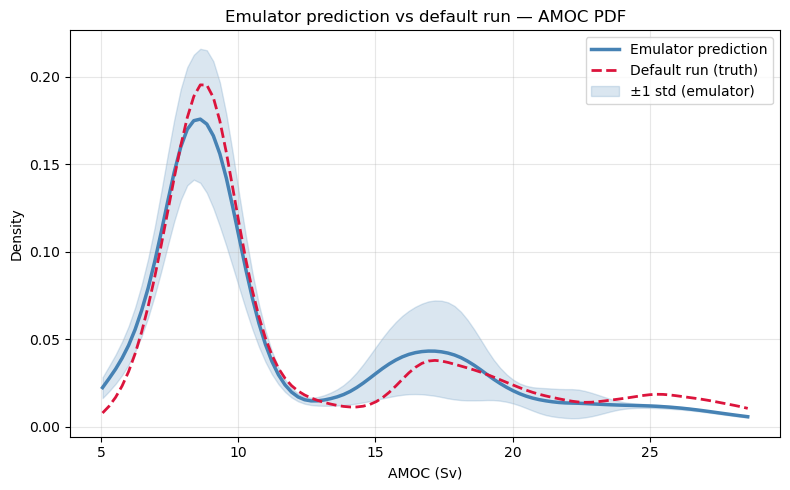

In [21]:
# Compare predicted vs true PDF for the default run
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(global_x_grid, pdf_pred_def[0], color='steelblue', lw=2.5,
        label='Emulator prediction')
if default_stats is not None:
    ax.plot(global_x_grid, default_stats['pdf'], color='crimson', lw=2,
            ls='--', label='Default run (truth)')

# Shade ± 1 std of the reconstructed PDF (propagated from pca_std)
# Approximate envelope: vary each PCA component by ±1 std independently
pdf_samples = []
for _ in range(200):
    pca_s = pca_pred_def[0] + pca_std_def[0] * np.random.randn(N_PCA)
    pdf_samples.append(emulator.reconstruct_pdf(pca_s, x_grid=global_x_grid))
pdf_samples = np.array(pdf_samples)
ax.fill_between(global_x_grid, pdf_samples.mean(0) - pdf_samples.std(0),
                                pdf_samples.mean(0) + pdf_samples.std(0),
                color='steelblue', alpha=0.2, label='±1 std (emulator)')

ax.set_xlabel('AMOC (Sv)')
ax.set_ylabel('Density')
ax.set_title('Emulator prediction vs default run — AMOC PDF')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()